In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from ariel_pred.dataset import DataLoaderAndCalibrator
from ariel_pred.preprocessing import SGSmoothing
from ariel_pred.plots import plot_white_curve
from ariel_pred.transit import FunctionFittingBasedPhaseDetector
from ariel_pred.models import TransitMultiplicationFactorFinder
from ariel_pred.features import WavelengthsGroupsMultiplierFinder
from ariel_pred.metrics import score
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random
from scipy.optimize import minimize
from tqdm.auto import tqdm
import pandas as pd

In [9]:
data_loader = DataLoaderAndCalibrator(
    data_path=Path("../data/raw"),
    output_path=Path("../data/calibrated/full"),
    force_recalibration=False,
    cut_airs_channels=True,
    binning=4,
    n_jobs=4
)
train_data, train_labels = data_loader.load_all_train_data()
train_data.shape, train_labels.shape

Loading calibrated train data...


((1100, 1406, 283), (1100, 283))

In [12]:
features_extractor = WavelengthsGroupsMultiplierFinder()

features, transit_locations = features_extractor.extract_features(train_data, return_transit_locations=True)
features.shape, transit_locations.shape

100%|██████████| 1100/1100 [03:52<00:00,  4.73it/s]


((1100, 283), (1100, 4))

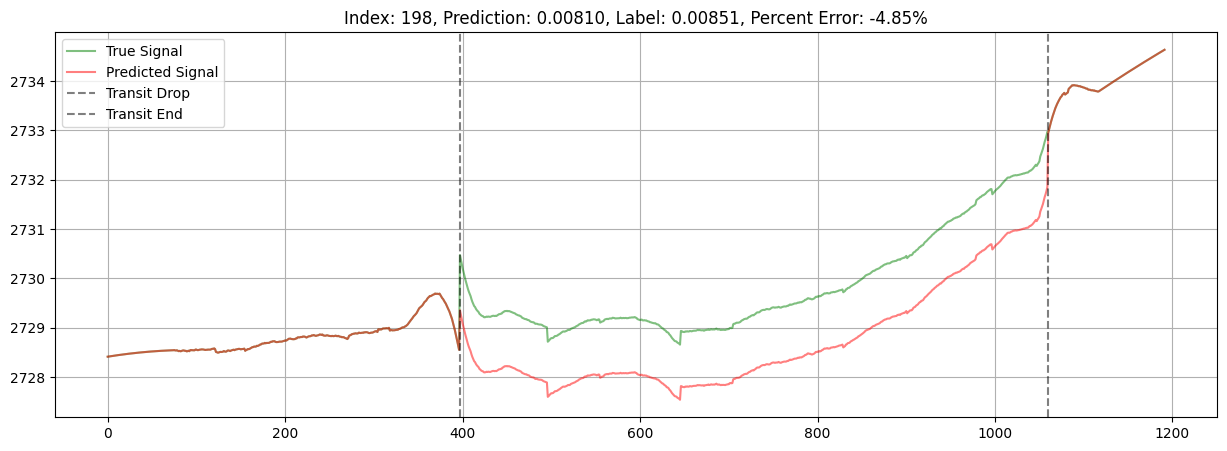

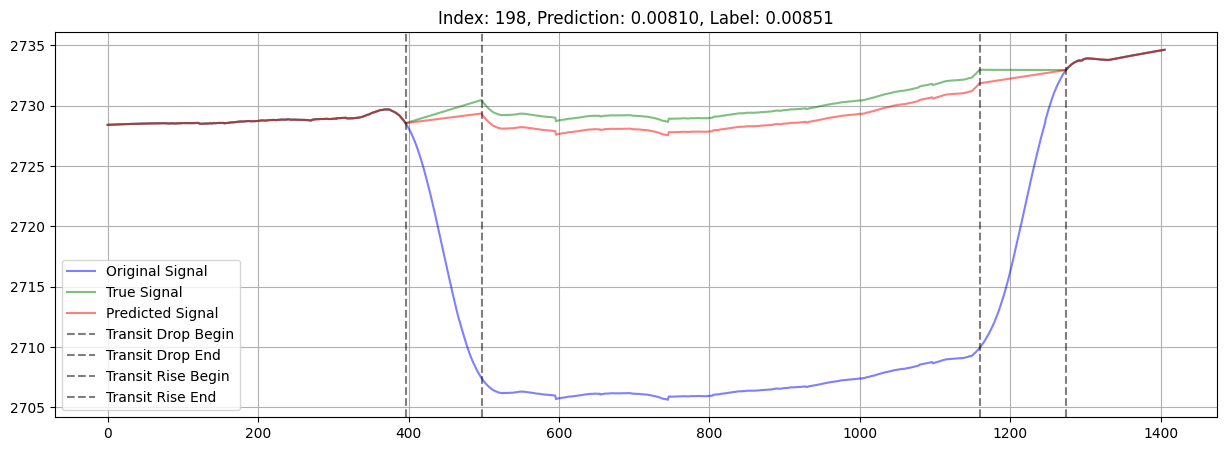

In [184]:
random_index = random.randint(0, train_data.shape[0] - 1)
# random_index = 42
wavelengths = np.arange(283)
smoother = SGSmoothing(window_size=150, poly_order=2)

signal = smoother.smooth(train_data[random_index][:, wavelengths].mean(axis=1))
prediction = features[random_index][wavelengths].mean()
prediction = prediction * 0.95
label = train_labels[random_index][wavelengths].mean()
t0, t1, t2, t3 = transit_locations[random_index]

predicted_signal = np.concatenate([
    signal[:t0],
    signal[t1:t2] * (1.0+prediction),
    signal[t3:]
])

true_signal = np.concatenate([
    signal[:t0],
    signal[t1:t2] * (1.0+label),
    signal[t3:]
])

plt.figure(figsize=(15, 5))
plt.title(f"Index: {random_index}, Prediction: {prediction:.5f}, Label: {label:.5f}, Percent Error: {((prediction-label)/label)*100:.2f}%")
plt.plot(true_signal, label="True Signal", alpha=0.5, color="green")
plt.plot(predicted_signal, label="Predicted Signal", alpha=0.5, color="red")
plt.axvline(t0, color="black", linestyle="--", alpha=0.5, label="Transit Drop")
plt.axvline(t2 - (t1-t0), color="black", linestyle="--", alpha=0.5, label="Transit End")
plt.legend()
plt.grid()
plt.show()  


plt.figure(figsize=(15, 5))
plt.title(f"Index: {random_index}, Prediction: {prediction:.5f}, Label: {label:.5f}")
plt.plot(signal, label="Original Signal", alpha=0.5, color="blue")
x = np.concatenate([
    np.arange(t0),
    np.arange(t1, t2),
    np.arange(t3, len(signal))
])
plt.plot(x, true_signal, label="True Signal", alpha=0.5, color="green")
plt.plot(x, predicted_signal, label="Predicted Signal", alpha=0.5, color="red")
plt.axvline(t0, color="black", linestyle="--", alpha=0.5, label="Transit Drop Begin")
plt.axvline(t1, color="black", linestyle="--", alpha=0.5, label="Transit Drop End")
plt.axvline(t2, color="black", linestyle="--", alpha=0.5, label="Transit Rise Begin")
plt.axvline(t3, color="black", linestyle="--", alpha=0.5, label="Transit Rise End")
plt.legend()
plt.grid()
plt.show()  

In [121]:
signal.shape[0]

1406

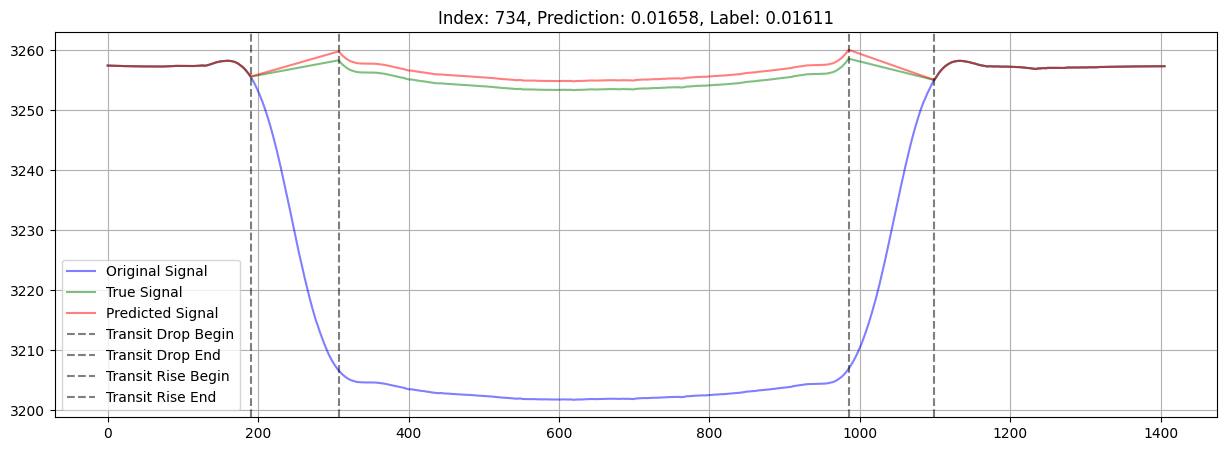

In [89]:
plt.figure(figsize=(15, 5))
plt.title(f"Index: {random_index}, Prediction: {prediction:.5f}, Label: {label:.5f}")
plt.plot(signal, label="Original Signal", alpha=0.5, color="blue")
x = np.concatenate([
    np.arange(t0),
    np.arange(t1, t2),
    np.arange(t3, len(signal))
])
plt.plot(x, true_signal, label="True Signal", alpha=0.5, color="green")
plt.plot(x, predicted_signal, label="Predicted Signal", alpha=0.5, color="red")
plt.axvline(t0, color="black", linestyle="--", alpha=0.5, label="Transit Drop Begin")
plt.axvline(t1, color="black", linestyle="--", alpha=0.5, label="Transit Drop End")
plt.axvline(t2, color="black", linestyle="--", alpha=0.5, label="Transit Rise Begin")
plt.axvline(t3, color="black", linestyle="--", alpha=0.5, label="Transit Rise End")
plt.legend()
plt.grid()
plt.show()  

In [185]:
df = pd.DataFrame(features - train_labels)

In [186]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,273,274,275,276,277,278,279,280,281,282
0,0.001371,0.001573,0.001575,0.001577,0.001578,0.001551,0.001550,0.001550,0.001550,0.001554,...,0.001003,0.001000,0.000793,0.000788,0.000787,0.000784,0.000695,0.000691,0.000687,0.000684
1,-0.000247,-0.000243,-0.000243,-0.000243,-0.000243,-0.000249,-0.000248,-0.000248,-0.000247,-0.000264,...,0.000078,0.000079,0.000064,0.000065,0.000065,0.000065,0.000260,0.000259,0.000259,0.000259
2,0.005466,0.005389,0.005397,0.005410,0.005421,0.005412,0.005409,0.005405,0.005406,0.005412,...,0.004466,0.004477,0.004469,0.004462,0.004459,0.004453,0.004699,0.004707,0.004712,0.004713
3,0.000386,0.000361,0.000363,0.000363,0.000363,0.000396,0.000397,0.000397,0.000397,0.000372,...,0.000039,0.000039,0.000115,0.000117,0.000117,0.000118,0.000078,0.000080,0.000080,0.000080
4,0.001163,0.001001,0.001009,0.001002,0.000994,0.001003,0.001009,0.001011,0.001006,0.001026,...,0.000541,0.000548,0.000475,0.000482,0.000473,0.000486,0.000626,0.000597,0.000581,0.000607


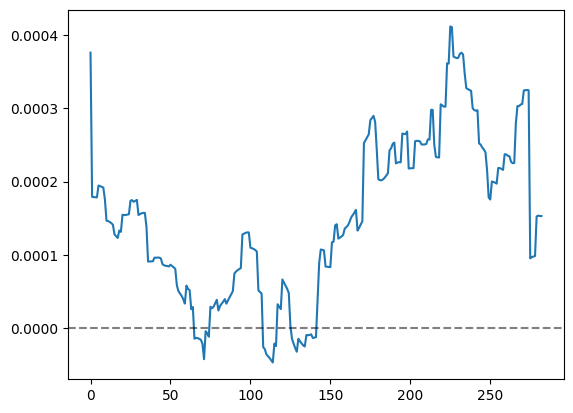

In [214]:
random_index = random.randint(0, train_data.shape[0] - 1)

plt.plot(df.iloc[random_index])
plt.axhline(0, color="black", linestyle="--", alpha=0.5)

In [216]:
df.sum()

0      0.849560
1      0.873500
2      0.878224
3      0.883972
4      0.889806
         ...   
278    0.762003
279    0.767724
280    0.765784
281    0.769680
282    0.774813
Length: 283, dtype: float64

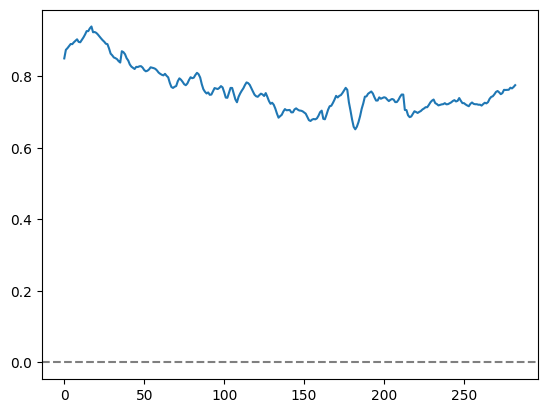

In [221]:
plt.plot(df.sum())
plt.axhline(0, color="black", linestyle="--", alpha=0.5)

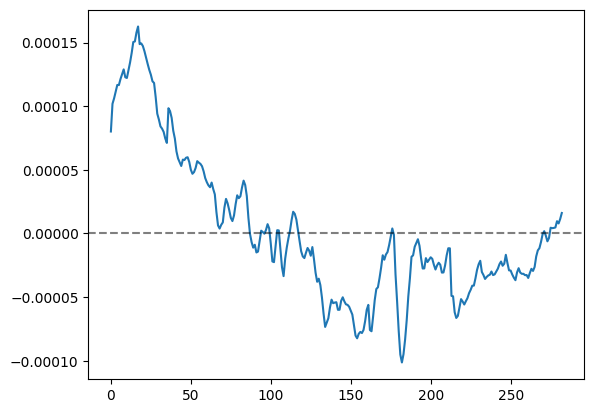

In [231]:
plt.plot((features * 0.955 - train_labels).mean(axis=0))
plt.axhline(0, color="black", linestyle="--", alpha=0.5)

In [ ]:
sigma = 0.0009
multiplier = 0.955
score(
    pd.DataFrame(train_labels).reset_index(),
    pd.DataFrame(np.concatenate([
        features * multiplier, np.full(features.shape, 0.0009)
    ], axis=1)).reset_index(),
    row_id_column_name="index",
    naive_mean=train_labels.mean(),
    naive_sigma=train_labels.std()
)

0.3276148148029438

In [ ]:
def score_from_sigma_and_multiplier(sigma=0.0009, multiplier=0.955):
    return score(
        pd.DataFrame(train_labels).reset_index(),
        pd.DataFrame(np.concatenate([
            features * multiplier, np.full(features.shape, sigma)
        ], axis=1)).reset_index(),
        row_id_column_name="index",
        naive_mean=train_labels.mean(),
        naive_sigma=train_labels.std()
    )
    
score_from_sigma_and_multiplier(0.000, multiplier), score_from_sigma_and_multiplier(0.00085, multiplier), score_from_sigma_and_multiplier(0.00090, multiplier)

(0.3314253842760784, 0.3298040876980139, 0.3276148148029438)

In [244]:
def cost_function(params):
    sigma, multiplier = params
    return -score_from_sigma_and_multiplier(sigma, multiplier)

initial_guess = [0.0009, 0.955]
result = minimize(cost_function, initial_guess, method='Nelder-Mead')
optimal_sigma, optimal_multiplier = result.x
optimal_sigma, optimal_multiplier, -result.fun

(np.float64(0.0007150756107276536),
 np.float64(0.9452534431182431),
 np.float64(0.3359089745881065))

In [245]:
score_from_sigma_and_multiplier(0.000715, 0.945)

0.3359057273038888